# Regression Metrics

Follow _Introduction to Machine Learning_ [Chapter 5](https://github.com/amueller/introduction_to_ml_with_python/blob/master/05-model-evaluation-and-improvement.ipynb) **Section 5.3.4 Regression Metrics** (p.306)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import mglearn

## Regression metrics

R-squared `sklearn.metrics.r2_score`
>It represents the proportion of variance (of y) that has been explained by the independent variables in the model. It provides an indication of goodness of fit and therefore a measure of how well unseen samples are likely to be predicted by the model, through the proportion of explained variance.

see [Coefficient of determination](https://en.wikipedia.org/wiki/Coefficient_of_determination) for more information.

$\frac{\sum(y - \bar{y})^2 - \sum(y - \hat{y})^2}{\sum(y - \bar{y})^2} = 1 -  \frac{\sum(y - \hat{y})^2}{\sum(y - \bar{y})^2}$

Mean-squared error `sklearn.metrics.mean_squared_error`

$\frac{1}{N} \sum (y - \hat{y})^2$

Root mean-squared error `sklearn.metrics.mean_squared_error(squared=False)`

$\sqrt{\frac{1}{N} \sum (y - \hat{y})^2}$

Mean absolute error `sklearn.metrics.mean_absolute_error`


$\frac{1}{N} \sum |y - \hat{y}|$

In [3]:
y = 10*np.random.rand(50)+2
y

array([ 5.1488692 , 11.85838471, 11.71470328,  6.32725337,  2.83983902,
        2.95397213,  4.32371539,  5.15694602,  9.09515368,  2.48147524,
        6.26043293,  5.28714951,  9.6499834 ,  5.23584664,  2.87641618,
        3.51779604,  9.48760189,  2.35905075,  6.93957127,  6.86925385,
       10.63447697,  2.90151936,  4.71028012,  7.13710352,  8.41889754,
        5.78095762,  9.8903354 ,  4.04756341,  7.88705835, 11.62079573,
       11.866851  ,  8.05057023,  6.94596438, 10.55769187,  8.2899249 ,
        6.61004406,  4.26364863,  2.8013348 ,  3.44145219,  2.74248904,
        2.5691262 ,  4.31299729,  8.11219811,  4.9529776 ,  3.53610394,
        4.59593331,  5.18567683,  5.67044519,  8.27762827,  6.61366528])

In [4]:
y_pred = y + 2*np.random.rand(50)
y_pred[-1] = 1.6 * y[-1] #a slight outlier
y_pred

array([ 6.92173803, 12.50549691, 13.40690443,  6.94204941,  3.88212677,
        3.56629272,  6.04572783,  7.0329871 , 10.76360934,  3.35995079,
        6.70004872,  5.99483956,  9.74277514,  6.86849447,  4.07283954,
        4.83140323, 11.1828242 ,  2.49365962,  7.77973755,  7.24183705,
       12.40574289,  3.44651173,  5.37917536,  8.80660399,  9.42247969,
        6.23066434, 11.83495606,  5.90160703,  8.41036494, 12.9671529 ,
       12.46677497,  9.84930377,  7.81076761, 11.47700811,  9.34876075,
        8.18390438,  4.92037455,  3.26983336,  3.80184923,  3.64505176,
        3.08583859,  6.07352301,  9.97270865,  6.38007322,  5.32494847,
        5.20500755,  5.21447637,  6.50518227,  8.73157823, 10.58186445])

### Predicted vs actual plot

Combined with a line of unity to assess biases in predictons.

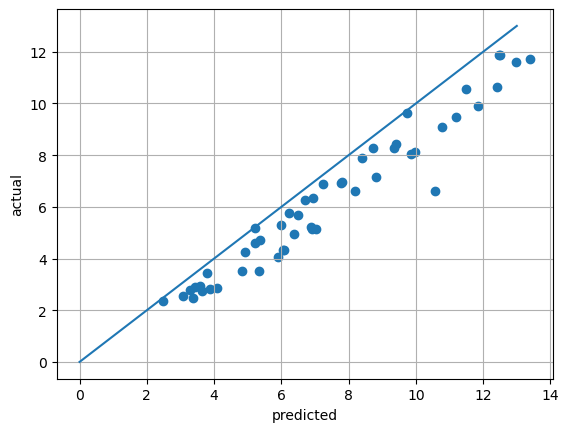

In [5]:
plt.scatter(y_pred, y)
plt.plot([0, 13], [0, 13])
plt.xlabel('predicted')
plt.ylabel('actual')
plt.grid(True)

### Residual plot

Assess distribution of errors and dependency on magnitude of predicted value.

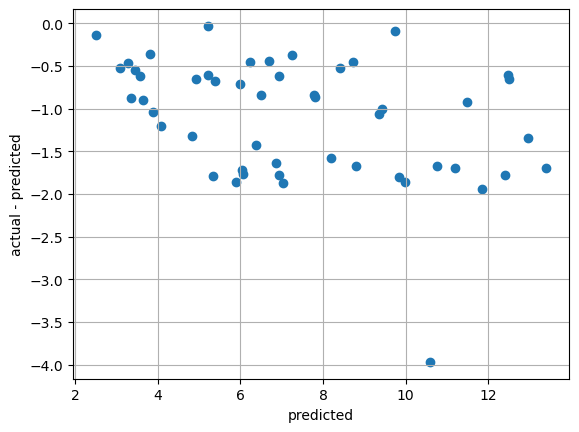

In [6]:
plt.scatter(y_pred, y-y_pred)
plt.xlabel('predicted')
plt.ylabel('actual - predicted')
plt.grid(True)

In [7]:
# Calculate R2 manually
1 - sum((y-y_pred)**2)/sum((y-y.mean())**2)

0.7824022985941761

In [8]:
from sklearn.metrics import r2_score
r2_score(y, y_pred)

0.7824022985941761

In [9]:
# Calculate mse manually
sum((y-y_pred)**2) / len(y)

1.704368134064506

In [10]:
from sklearn.metrics import mean_squared_error as mse
mse(y, y_pred)

1.704368134064506

In [11]:
# Calculate rms manually
np.sqrt(sum((y-y_pred)**2) / len(y))

1.3055145093274552

In [12]:
mse(y, y_pred, squared=False)

1.3055145093274552

In [13]:
# Calculate mae manually
sum(np.abs(y-y_pred)) / len(y)

1.1036060989208338

In [14]:
from sklearn.metrics import mean_absolute_error as mae
mae(y, y_pred)

1.1036060989208338

## Negative $R^2$?

In [15]:
x = np.linspace(0, 10, 50)
x

array([ 0.        ,  0.20408163,  0.40816327,  0.6122449 ,  0.81632653,
        1.02040816,  1.2244898 ,  1.42857143,  1.63265306,  1.83673469,
        2.04081633,  2.24489796,  2.44897959,  2.65306122,  2.85714286,
        3.06122449,  3.26530612,  3.46938776,  3.67346939,  3.87755102,
        4.08163265,  4.28571429,  4.48979592,  4.69387755,  4.89795918,
        5.10204082,  5.30612245,  5.51020408,  5.71428571,  5.91836735,
        6.12244898,  6.32653061,  6.53061224,  6.73469388,  6.93877551,
        7.14285714,  7.34693878,  7.55102041,  7.75510204,  7.95918367,
        8.16326531,  8.36734694,  8.57142857,  8.7755102 ,  8.97959184,
        9.18367347,  9.3877551 ,  9.59183673,  9.79591837, 10.        ])

In [16]:
np.random.seed(345)
y = -0.1*x**2+np.random.randn(50)+8
y

array([ 9.46924823,  6.84569076, 10.50256581,  7.88003797,  7.8997602 ,
        6.25922111,  7.43796999,  9.58086739,  7.77582735,  7.04290855,
        6.59181629,  7.63251063,  8.05693087,  6.79971652,  6.951097  ,
        7.4427832 ,  7.46915178,  5.60221996,  5.13612727,  6.61246535,
        6.59305291,  7.2294732 ,  5.54417131,  3.64972928,  4.88234632,
        4.94052172,  4.06125135,  4.32530868,  4.32878758,  4.89270049,
        3.71259272,  3.38735709,  4.12353015,  3.60141911,  3.04174249,
        3.07343655,  2.56404523,  3.52795518,  1.18175509,  1.22677715,
        1.70050085,  0.49168713, -1.27354158, -0.30594167, -1.64670799,
       -0.9954155 , -0.16744344, -0.87718239, -1.81255468, -2.80012579])

Text(0, 0.5, 'target')

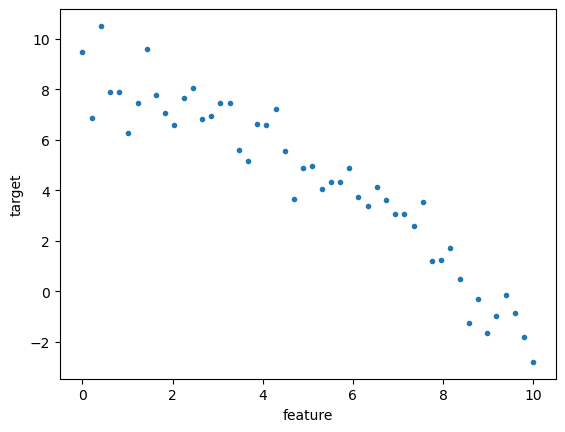

In [17]:
plt.plot(x, y, '.');
plt.xlabel('feature')
plt.ylabel('target')

In [18]:
from sklearn.linear_model import LinearRegression

In [19]:
model = LinearRegression(fit_intercept=False)
model.fit(x[:,None],y).score(x[:,None],y)

-1.338864672807301

Text(0, 0.5, 'target')

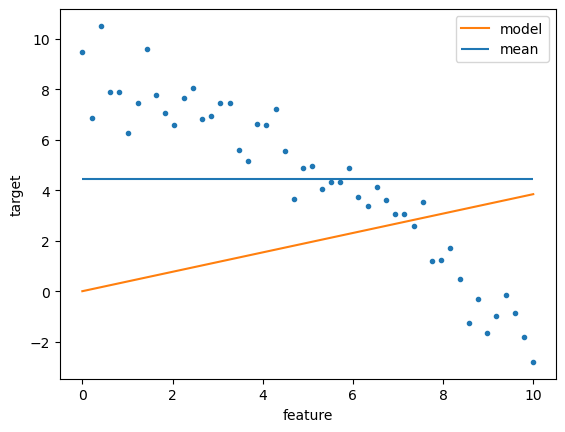

In [20]:
xline = np.linspace(0, 10, 20)
y_pred = model.predict(xline[:,None])

plt.plot(x, y, '.');
plt.plot(xline, y_pred, label='model');
plt.hlines(y=y.mean(), xmin=0, xmax=10, label='mean')
plt.legend()
plt.xlabel('feature')
plt.ylabel('target')

Why do we get a negative $R^2$?

It is possible to get a negative $R^2$ when the model performs worse than the constant-mean predictor

$R^2 = 1 -  \frac{\sum(y - \hat{y})^2}{\sum(y - \bar{y})^2}$

For a *bad* model, the numerator will be larger than the denominator, making the value negative.

For linear regression it can happen when no intercept is fitted.

See:

https://stackoverflow.com/questions/30507245/negative-r2-on-training-data-for-linear-regression

https://stats.stackexchange.com/questions/12900/when-is-r-squared-negative